# 02 — Preprocessing

---

## Objective

Transform the raw dataframe from EDA into two clean, ready-to-use dataframes:
- `df_survival.csv` → for Kaplan-Meier and Cox notebooks (clinical variables + biomarkers + top genes)
- `df_ml.csv` → for ML notebook (clinical variables + biomarkers + selected genomics)

---

## Notebook Outline

0. Setup & Loading  
1. Target Variable Recoding  
2. Exclusion of Unusable Variables  
3. Variable Blocks Redefinition  
4. log1p Transformations
5. `_mut` Columns Binarization  
6. Imputation & Encoding (pipeline)  
7. Genomic Feature Selection  
8. Export Dataframes

## 0. Setup & Loading

We start from the raw file to keep complete traceability —
preprocessing never modifies the source file.

We immediately save a copy `df_raw` to be able to compare
distributions before/after transformation without reloading the file.

In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
import os

DATA_PATH = r"../data/METABRIC_RNA_Mutation.csv"
df = pd.read_csv(DATA_PATH, low_memory=False)
df_raw = df.copy()  # save for before/after comparison

print(f"✅ {df.shape[0]} patients, {df.shape[1]} variables")

✅ 1904 patients, 693 variables


## 1. Target Variable Recoding

In METABRIC, `overall_survival` is encoded inversely to the standard
convention used by `lifelines` and `scikit-survival`:

| Original Value | Meaning | lifelines Convention |
|---|---|---|
| `overall_survival = 0` | death | must be `event = 1` |
| `overall_survival = 1` | alive | must be `event = 0` |

We create a new column `event = 1 - overall_survival`.
We keep `overall_survival_months` intact — it is the follow-up duration
needed for KM curves and the Cox model.

In [34]:
df["event"] = 1 - df["overall_survival"]
print("=" * 20 + "\n ✅ Recoding check: \n" + "=" * 20)

surv_check = (
    df.groupby("event")["overall_survival_months"]
    .median()
    .round(1)
    .reset_index(name="Median Survival (mounths)")
)
# event=0 (alive) → median ~158 months
# event=1 (death) → median ~86 months 
display(surv_check)

 ✅ Recoding check: 


,event,Median Survival (mounths)
0,0,158.0
1,1,85.9


> ✅ **Recoding Confirmed**:
> - `event = 0` (alive) → median follow-up ~158 months
> - `event = 1` (death) → median follow-up ~86 months
>
> The gradient is consistent with the EDA. `event` will be the censoring variable
> in all survival models.

## 2. Exclusion of Unusable Variables

We remove variables identified in EDA as unusable in modeling.
Each exclusion is justified independently. 

A variable excluded for a bad reason can lead to the loss of valuable information.

In [35]:
print("=" * 20 + "\n Columns dropped: \n" + "=" * 20)

cols_to_drop = [
    "tumor_stage",                  # MNAR (28% missing in death vs 24% alive)
    "3-gene_classifier_subtype",    # 10.7% missing, technical origin
    "primary_tumor_laterality",     # 5.6% missing, uninformative for survival
    "er_status_measured_by_ihc",    # duplicate of er_status
    "her2_status_measured_by_snp6", # duplicate of her2_status
    "patient_id",                   # identifier, uninformative
    "overall_survival",             # replaced by event
    "death_from_cancer",            # data leakage : available only after the event
    "oncotree_code",                # redundant with cancer_type_detailed
]

cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df = df.drop(columns=cols_to_drop)

print(f"✅ {len(cols_to_drop)} columns dropped")
print(f"Shape : {df.shape}")

 Columns dropped: 
✅ 9 columns dropped
Shape : (1904, 685)


> **`death_from_cancer` - data leakage**:
> This variable indicates the cause of death. It is linked to the outcome
> by design, including it in a model would constitute data leakage:
> the model would use information available only after the event
> we are trying to predict.
>
> **`tumor_stage` - MNAR**:
> 26.3% missing with a significantly higher rate among deceased (28%)
> than among alive (24%). Imputation is impossible without bias.
> The Nottingham Prognostic Index (NPI) is retained as a proxy (r=0.55, consistent gradient).

## 3. Variable Blocks Redefinition

In the EDA notebook, blocks included variables since removed
(`tumor_stage`, `death_from_cancer`, `patient_id`...). We redefine
blocks here on the cleaned dataframe after exclusions.

| Block | Planned Processing |
|---|---|
| `target_cols` | Target variables: excluded from preprocessing |
| `treatment_cols` | Already in int64: no encoding needed |
| `biomarker_cols` | Included in the binary pipeline |
| `mut_cols` | str with variants → binarization (0/1) before pipeline |
| `expr_cols` | float64: passthrough in the pipeline |
| `clinical_cols` | Imputation + encoding according to type |

In [40]:
print("=" * 30 + "\n Variable Blocks Redefinition: \n" + "=" * 30)

target_cols    = ["overall_survival_months", "event"]
treatment_cols = ["chemotherapy", "hormone_therapy", "radio_therapy"]
biomarker_cols = ["er_status", "pr_status", "her2_status"]
mut_cols       = [c for c in df.columns if c.endswith("_mut")]
clinical_cols  = [
    "age_at_diagnosis", "type_of_breast_surgery", "cancer_type",
    "cancer_type_detailed", "cellularity", "cohort",
    "neoplasm_histologic_grade", "tumor_other_histologic_subtype",
    "inferred_menopausal_state", "integrative_cluster",
    "lymph_nodes_examined_positive", "mutation_count",
    "nottingham_prognostic_index", "pam50_+_claudin-low_subtype", "tumor_size"
]

already_assigned = target_cols + treatment_cols + biomarker_cols + mut_cols + clinical_cols
expr_cols = [c for c in df.columns if c not in already_assigned]

groups = {
    "Target": target_cols,
    "Treatments": treatment_cols,
    "Biomarkers": biomarker_cols,
    "Mutations": mut_cols,
    "Clinical": clinical_cols,
    "Expression": expr_cols,
}

summary = pd.DataFrame({
    "Variables": {k: len(v) for k, v in groups.items()}
})

summary.loc["Total"] = summary.sum()

display(summary)
total = summary.loc["Total", "Variables"]
print(f"Check: {total} / {df.shape[1]} {'✅' if total == df.shape[1] else '⚠️'}")

 Variable Blocks Redefinition: 


,Variables
Target,2
Treatments,3
Biomarkers,3
Mutations,173
Clinical,15
Expression,489
Total,685


Check: 685 / 685 ✅


> The blocks are well defined and cover all 685 columns.
> `expr_cols` recovers by exclusion anything not explicitly assigned,
> ensures no column is forgotten.

## 4. log1p Transformations

Two variables show **strong right skewness** identified in EDA:
- `mutation_count`: max=80, widely spread distribution
- `tumor_size`: right tail with 3 values > 150mm

log1p (`log(1+x)`) compresses extreme values and brings the distribution
closer to a normal distribution, which StandardScaler implicitly assumes.

This transformation must be applied **before the pipeline** so that
StandardScaler works on the already transformed values.

In [22]:
print("=" * 25 + "\n log1p Transformations: \n" + "=" * 25)

df["mutation_count"] = np.log1p(df["mutation_count"])
df["tumor_size"]     = np.log1p(df["tumor_size"])
print("✅ log1p applied on mutation_count et tumor_size")

 log1p Transformations: 
✅ log1p applied on mutation_count et tumor_size


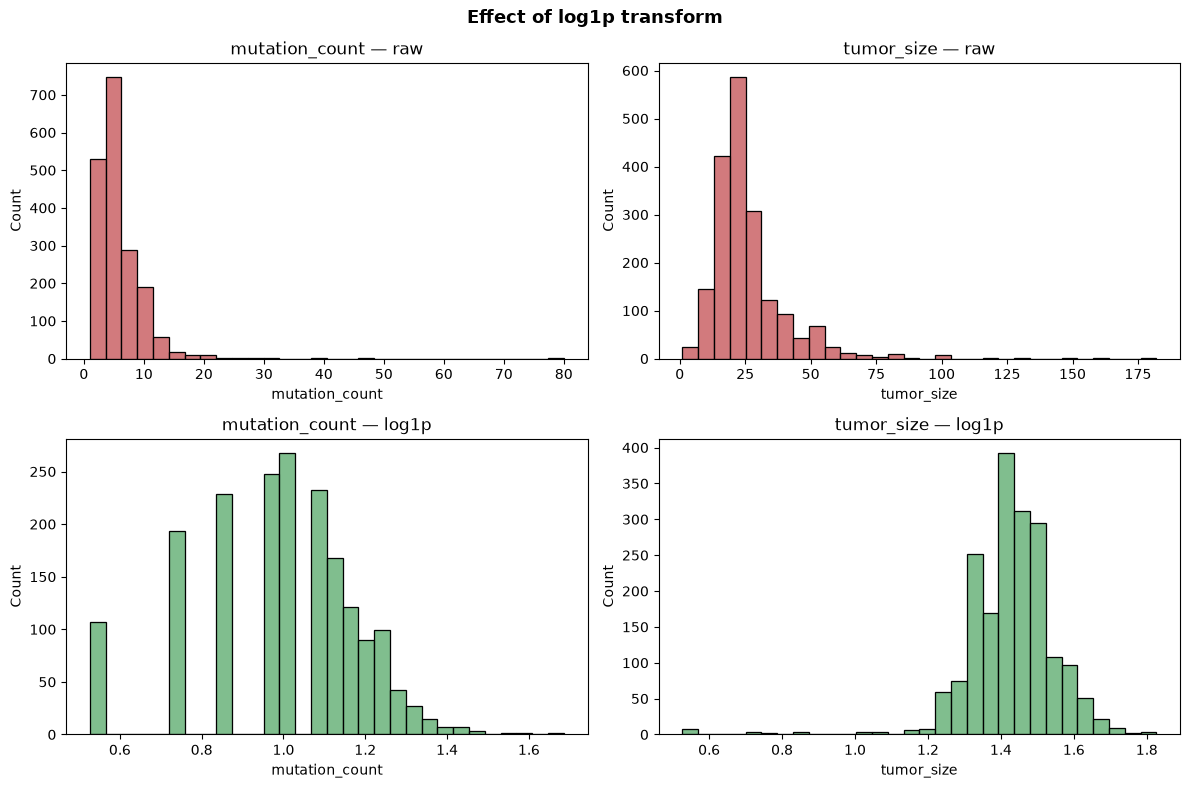

In [23]:
# Before/after visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Effect of log1p transform", fontsize=13, fontweight="bold")

sns.histplot(df_raw["mutation_count"].dropna(), bins=30, ax=axes[0,0], color="#C44E52")
axes[0,0].set_title("mutation_count — raw")

sns.histplot(df_raw["tumor_size"].dropna(), bins=30, ax=axes[0,1], color="#C44E52")
axes[0,1].set_title("tumor_size — raw")

sns.histplot(df["mutation_count"].dropna(), bins=30, ax=axes[1,0], color="#55A868")
axes[1,0].set_title("mutation_count — log1p")

sns.histplot(df["tumor_size"].dropna(), bins=30, ax=axes[1,1], color="#55A868")
axes[1,1].set_title("tumor_size — log1p")

plt.tight_layout()
os.makedirs("../outputs/figures", exist_ok=True)
plt.savefig("../outputs/figures/02_log1p.png", dpi=150, bbox_inches="tight")
plt.show()

> log1p significantly reduces the skewness of `mutation_count`
> (spread right tail → more symmetric distribution).
>
> For `tumor_size`, the effect is less pronounced but the 3 extreme values
> (> 150mm) have their influence reduced, consistent with the decision
> to keep them without deletion.

## 5. `_mut` Columns Binarization

Mutation columns contain **variant names** (e.g. `H1047R`, `E542K`)
and not binary values. For models, we only need to know
if a mutation is **present (1) or absent (0)**.

This step must be done **before the pipeline** because ColumnTransformer
cannot interpret strings as genomic variants.

In [24]:
print("=" * 30 + "\n _mut Columns Binarization: \n" + "=" * 30)

df[mut_cols] = df[mut_cols].apply(lambda col: col.map(lambda x: 0 if x == '0' else 1))

print(f"✅ {len(mut_cols)} _mut columns binarized")
print(f"Example — pik3ca_mut : {df['pik3ca_mut'].value_counts().to_dict()}")

 _mut Columns Binarization: 
✅ 173 _mut columns binarized
Example — pik3ca_mut : {1: 1904}


> Binarization transforms each variant into presence/absence.
> We lose information on the variant type (e.g. H1047R vs E545K) but
> this granularity is beyond the scope of this project. It would require
> a pathogenicity analysis specific to each variant.

## 6. Imputation & Encoding

We apply differentiated strategies according to variable type,
in line with decisions made in EDA:

| Variable | Imputation | Encoding | Justification |
|---|---|---|---|
| `tumor_size`, `mutation_count` | Median | StandardScaler | Skewed continuous variables; median robust to extremes |
| `age_at_diagnosis`, `nottingham_prognostic_index`, `lymph_nodes_examined_positive`, `cohort` | None | StandardScaler | No missing, already numerical |
| `cellularity` | Mode | OrdinalEncoder (Low=0, Moderate=1, High=2) | Ordinal variable; order must be preserved |
| `neoplasm_histologic_grade` | Mode | OrdinalEncoder (1.0=0, 2.0=1, 3.0=2) | Ordinal variable — grade 1 < 2 < 3 |
| `er_status`, `pr_status`, `her2_status`, `cancer_type`, `type_of_breast_surgery`, `inferred_menopausal_state` | Mode | OneHotEncoder `drop='if_binary'` | 2 modalities; prevents redundancy (one column is enough) |
| `cancer_type_detailed`, `tumor_other_histologic_subtype`, `pam50_+_claudin-low_subtype`, `integrative_cluster` | Mode | OneHotEncoder | > 2 modalities without order; prevents artificial hierarchy |

> ⚠️ **Data leakage**: the pipeline is fitted on the entire dataset
> to produce intermediate files. In the ML notebook,
> the pipeline will be fitted **only on the train set** then
> applied to the test set.

### Column Groups Definition

Each group is processed by a dedicated pipeline in ColumnTransformer.
The `remainder='passthrough'` parameter ensures that genomic columns
(expression + binarized mutations) and target variables are kept as is.

In [25]:
# ── Column Groups ──────────────────────────────────────────
num_cols    = ["tumor_size", "mutation_count"]

scale_cols  = ["age_at_diagnosis", "nottingham_prognostic_index",
               "lymph_nodes_examined_positive", "cohort"]

ord_cols        = ["cellularity", "neoplasm_histologic_grade"]
ord_categories  = [["Low", "Moderate", "High"], [1.0, 2.0, 3.0]]

binary_cols = ["er_status", "pr_status", "her2_status",
               "cancer_type", "type_of_breast_surgery",
               "inferred_menopausal_state"]

ohe_cols    = ["cancer_type_detailed", "tumor_other_histologic_subtype",
               "pam50_+_claudin-low_subtype", "integrative_cluster"]

# ── Pipelines ────────────────────────────────────────────────────
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

scale_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

ord_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(categories=ord_categories))
])

binary_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="if_binary", sparse_output=False, handle_unknown="ignore"))
])

ohe_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(sparse_output=False, handle_unknown="ignore"))
])

# ── ColumnTransformer ────────────────────────────────────────────
preprocessor = ColumnTransformer([
    ("num",    num_pipeline,    num_cols),
    ("scale",  scale_pipeline,  scale_cols),
    ("ord",    ord_pipeline,    ord_cols),
    ("binary", binary_pipeline, binary_cols),
    ("ohe",    ohe_pipeline,    ohe_cols)
], remainder="passthrough")

# ── Application ──────────────────────────────────────────────────
data_clean = preprocessor.fit_transform(df)
df_clean = pd.DataFrame(
    data_clean,
    columns=preprocessor.get_feature_names_out(),
    index=df.index
)
df_clean.columns = [c.split("__")[-1] for c in df_clean.columns]

# ── Verification ─────────────────────────────────────────────────
print(f"✅ Shape after preprocessing : {df_clean.shape}")
print(df_clean.dtypes.value_counts())
total_na = df_clean.isna().sum().sum()
print(f"Missing values : {total_na} {'✅' if total_na == 0 else '⚠️'}")

✅ Shape after preprocessing : (1904, 713)
float64    713
Name: count, dtype: int64
Missing values : 0 ✅


> **Result**:
> - **713 columns** : OneHotEncoders created additional columns
>   (`pam50`: 7 modalities → 7 columns, `integrative_cluster`: 11 → 11 columns)
> - **0 missing values** → all imputations worked ✅
> - **All in float64** → the dataset is ready for scikit-learn and lifelines
> - `drop='if_binary'` on binary variables: only one column per variable
>   (e.g., `er_status_Positive` only, no duplicate `er_status_Negative`)

## 7. Genomic Feature Selection

With 662 genomic variables (490 expression + 173 binarized mutations),
a Cox or ML model trained on all these variables would be unstable
and difficult to interpret. We apply two successive filters:

1. **VarianceThreshold**: removes quasi-constant variables.
   A mutation present in < 1% of patients has no usable predictive power.
2. **Correlation with `overall_survival_months`**: among remaining variables,
   we keep those with the strongest linear link to survival.

**Two output dataframes** because Cox and ML have different needs:
- `df_survival` → **top 25 genes**: Cox must remain parsimonious
  (rule of thumb: ~10 events per variable, so max ~80 variables for 801 deaths)
- `df_ml` → **top 50 genes**: Random Forest and XGBoost tolerate
  more features thanks to their internal regularization

In [43]:
target_cols_clean   = ["overall_survival_months", "event"]
mut_cols_clean      = [c for c in df_clean.columns if c.endswith("_mut")]
expr_cols_clean     = [c for c in df_clean.columns if c in expr_cols]
clinical_cols_clean = [c for c in df_clean.columns
                       if c not in target_cols_clean
                       and c not in mut_cols_clean
                       and c not in expr_cols_clean]
genomic_cols_clean  = mut_cols_clean + expr_cols_clean
df_genomic_clean    = df_clean[genomic_cols_clean]

summary_clean = pd.DataFrame({
    "Variables": [
        len(clinical_cols_clean),
        len(genomic_cols_clean),
        len(target_cols_clean)
    ]
}, index=["Clinical", "Genomic", "Target"])

summary_clean.loc["Total"] = summary_clean.sum()

display(summary_clean)

total = summary_clean.loc["Total", "Variables"]
print(f"Check: {total} / {df_clean.shape[1]} {'✅' if total == df_clean.shape[1] else '⚠️'}")

,Variables
Clinical,49
Genomic,662
Target,2
Total,713


Check: 713 / 713 ✅


> The 662 genomic variables correspond to the 490 expression columns
> and 173 binarized mutations.
>
> The 49 clinical columns include
> the expanded OHE variables (pam50 → 7 columns, integrative_cluster → 11 columns).

In [63]:
# ── 2. Filter 1: VarianceThreshold ──────────────────────────────

print("="*20 + "\n Variance Threshold \n" + "="*20)
var_selector = VarianceThreshold(threshold=0.01)

var_selector.fit_transform(df_genomic)

cols_var = df_genomic.columns[
    var_selector.get_support()
].tolist()

print(f"✅ After VarianceThreshold : {len(cols_var)} / {len(genomic_cols_clean)} variables")
print(f"   Variables dropped : {len(genomic_cols_clean) - len(cols_var)}")

# ── 3. Filter 2: Correlation with survival ─────────────────────
print("="*60 + "\n 🎯 Top 5 genomic variables most correlated with survival  \n" + "="*60)
correlations = df_clean[cols_var].apply(
    lambda x: x.corr(df_clean["overall_survival_months"])
)

correlations_abs = correlations.abs().sort_values(ascending=False)

top5_corr = correlations_abs.head(5).rename("Top 5 correlation")

display(top5_corr.to_frame().round(2))

print("="*20 + "\n Steps \n" + "="*20)

display(pd.DataFrame({
    "Step": [
        "Initial genomic variables",
        "After VarianceThreshold",
        "Selected for Cox",
        "Selected for ML"
    ],
    "Variables": [
        len(genomic_cols_clean),
        len(cols_var),
        TOP_N_SURVIVAL,
        TOP_N_ML
    ]
}))

 Variance Threshold 
✅ After VarianceThreshold : 489 / 662 variables
   Variables dropped : 173
 🎯 Top 5 genomic variables most correlated with survival  


,Top 5 correlation
sf3b1,0.18
pdpk1,0.17
bcl2,0.17
mapk14,0.17
tsc1,0.16


 Steps 


,Step,Variables
0,Initial genomic variables,662
1,After VarianceThreshold,489
2,Selected for Cox,25
3,Selected for ML,50


> **Results**:
> - **VarianceThreshold**: 662 → 489 variables (-26%) : 173 genes/mutations
>   quasi-constant removed (rare mutations present in < 1% of patients)
> - **Top 5 genes**: `sf3b1` (r=0.18), `pdpk1` (r=0.17), `bcl2` (r=0.17),
>   `mapk14` (r=0.17), `tsc1` (r=0.16)
>   → Moderate but biologically coherent correlations:
>   `bcl2` is an anti-apoptotic gene known as a prognostic biomarker
>   for breast cancer; `sf3b1` is involved in alternative splicing
>
> ⚠️ Pearson correlation only captures **linear** relationships.
> Genes with a non-linear relationship to survival may have been
> removed here. The Random Forest (notebook 05) may recover
> some of them via feature importances.

## 8. Dataframes Reconstruction & Export

We build the two final dataframes by combining:
- Preprocessed clinical variables
- The subset of selected genes (top 25 for Cox, top 50 for ML)
- Target variables (`overall_survival_months` + `event`)

Files are exported to `../data/processed/` to be loaded
directly in the next notebooks.

In [77]:
# ── Dataframes reconstruction
colonnes_survival = clinical_cols_clean + top_genomic_survival + target_cols_clean
colonnes_ml       = clinical_cols_clean + top_genomic_ml + target_cols_clean

df_survival = df_clean[colonnes_survival].copy()
df_ml = df_clean[colonnes_ml].copy()

display(pd.DataFrame({
        "Columns": [df_survival.shape[1], df_ml.shape[1]]
}, index=["df_survival", "df_ml"]))

print(f"df_survival : {df_survival.shape} {len(clinical_cols_clean)} clinical + {len(top_genomic_survival)} genes + {len(target_cols_clean)} targets")
print(f"df_ml       : {df_ml.shape} {len(clinical_cols_clean)} clinical + {len(top_genomic_ml)} genes + {len(target_cols_clean)} targets")

,Columns
df_survival,76
df_ml,101


df_survival : (1904, 76) 49 clinical + 25 genes + 2 targets
df_ml       : (1904, 101) 49 clinical + 50 genes + 2 targets


In [78]:
# ── Export 
os.makedirs("../data/processed", exist_ok=True)

df_survival.to_csv("../data/processed/df_survival.csv", index=False)
df_ml.to_csv("../data/processed/df_ml.csv",       index=False)

print(f"\n📁 Files exported in ../data/processed/")
for f in os.listdir("../data/processed/"):
    size = os.path.getsize(f"../data/processed/{f}") / 1024
    print(f"  {f} — {size:.1f} Ko")


📁 Files exported in ../data/processed/
  df_ml.csv — 1274.9 Ko
  df_survival.csv — 922.4 Ko


> **Preprocessing Summary**:
>
> | Step | Action | Result |
> |---|---|---|
> | Recoding | `event = 1 - overall_survival` | lifelines convention ✅ |
> | Exclusions | 9 columns removed | MNAR, leakage, duplicates |
> | Binarization | 173 `_mut` columns | 0/1 presence/absence |
> | log1p | `mutation_count`, `tumor_size` | Reduced skewness |
> | Pipeline | Imputation + encoding + StandardScaler | 0 missing, all in float64 |
> | Feature selection | 662 → 489 → top 25/50 genes | VarianceThreshold + correlation |
> | Export | `df_survival.csv`, `df_ml.csv` | Ready for KM, Cox and ML |
>
> **Next step**: `03_kaplan_meier.ipynb`